 Complete Case Analysis -> CCA tab apply karte hain jab data randomly missing hain .CCA  apply karne se pehle check karne chahiye ki data ko hatane ke pehle jo distributon hain aur data ko hatane ke baad jo distribution hain isme jyada difference nehi hona chahiye 

# When to use CCA ?
 1. Data should be missing completely at rendom .
 Agar kisi colm main 5% de jyada data missing hain toh CCA apply nehi kar sakte hain .
 aur agar data 95% missing hoti hain toh colm hi remove kar sakte hain
 We use CCA to remove rows with missing values and make data clean.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv(r"C:\Users\Dr.Sumedha\Downloads\data_science_job.csv")

In [7]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [8]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [10]:
df.shape

(19158, 13)

In [12]:
cols = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [13]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
4900,0.789,no_enrollment,Masters,10.0,79.0
229,0.926,no_enrollment,Masters,15.0,8.0
11391,0.884,Full time course,High School,7.0,110.0
2365,0.920,no_enrollment,Graduate,20.0,NaN
17720,0.735,no_enrollment,Masters,8.0,43.0


In [14]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [16]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


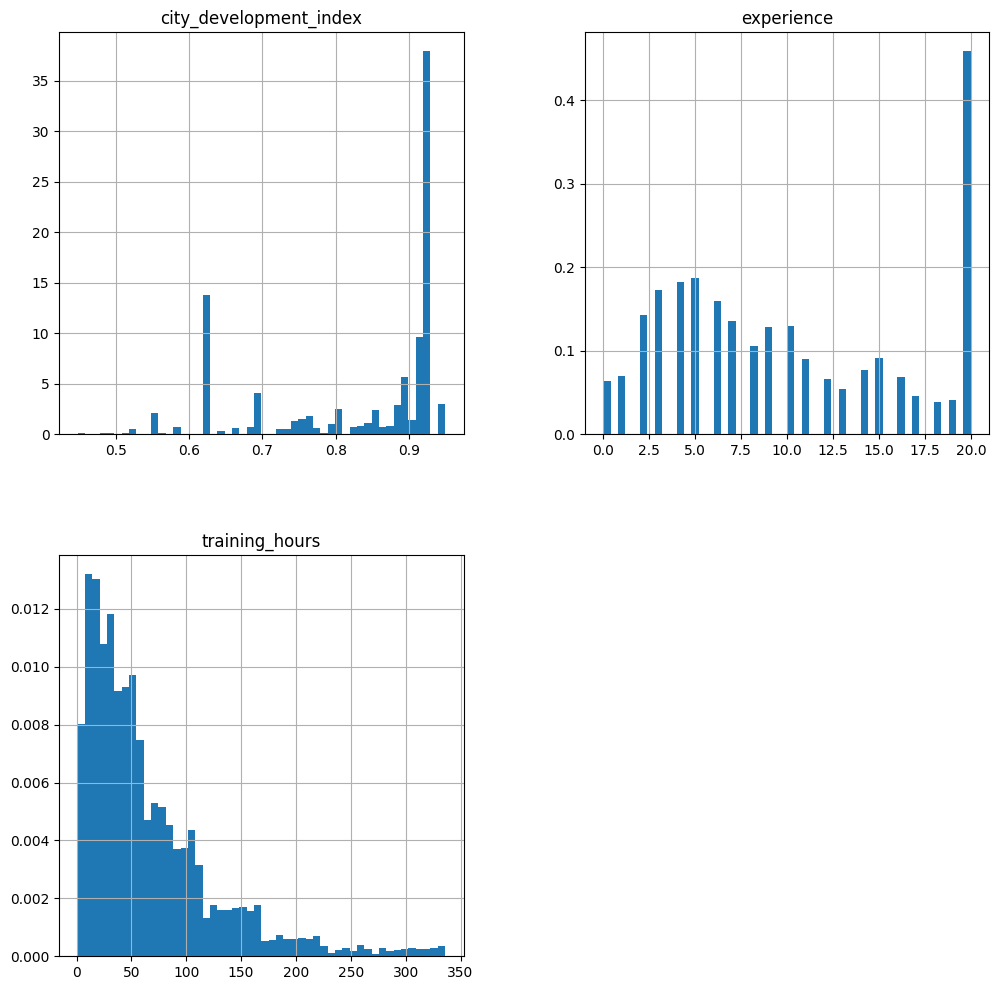

In [17]:
new_df.hist(bins=50 , density= True, figsize=(12,12))
plt.show()

<Axes: >

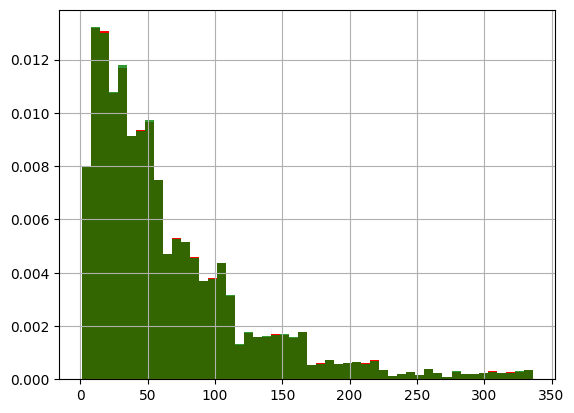

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df["training_hours"].hist(bins=50, ax = ax, density = True, color = "red")

# data after cca, the argument alpha makes the color transparent, so we can 
# see the overly of the 2 distribution
new_df["training_hours"].hist(bins = 50, ax = ax, color="green",density = True, alpha = 0.8)  # ax=ax → plot both graphs on same area, alpha → makes graph transparent so overlap is visible

In [27]:
print(df.columns.tolist())

['enrollee_id', 'city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'training_hours', 'target']


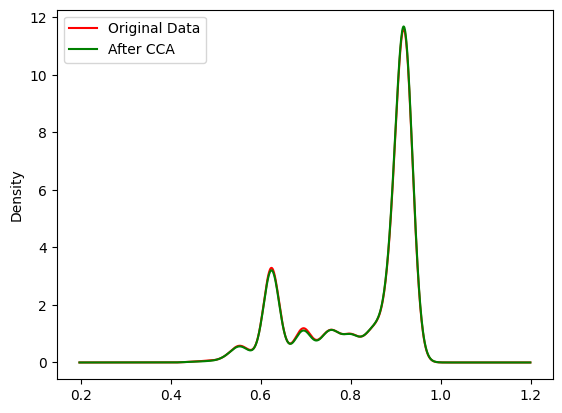

In [28]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111)

df["city_development_index"].plot.density(color="red")
new_df["city_development_index"].plot.density(color="green")

plt.legend(["Original Data", "After CCA"])
plt.show()

<Axes: >

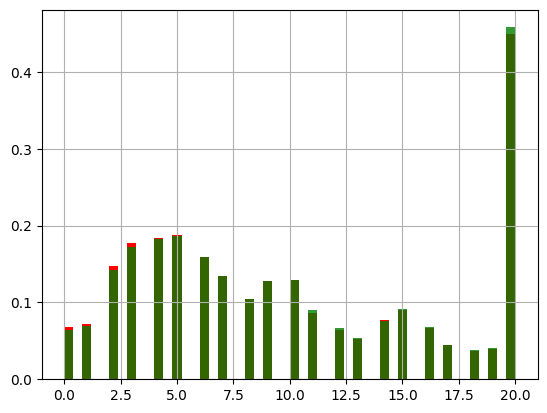

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df["experience"].hist(bins=50, ax = ax, density = True, color = "red")

# data after cca, the argument alpha makes the color transparent, so we can 
# see the overly of the 2 distribution
new_df["experience"].hist(bins = 50, ax = ax, color="green",density = True, alpha = 0.8)

In [ ]:
temp = pd.concat([ # percentage of observation per category,original data 
    df["enrolled_university"].value_counts() / len(new_df),# percentage of observations per category, cca data
                  new_df["enrolled_university"].value_counts() / len(new_df)],axis=1) 
# add columns names
temp.columns = ["original","cca"]
temp

,original,cca
enrolled_university,,
no_enrollment,0.804156,0.735188
Full time course,0.218659,0.200733
Part time course,0.069724,0.064079
